# Laboratorio 5

## Informe

## Capa RNN




### La **función de un RNN Elman (multi-layer)**

Para una **capa** de una red recurrente (Elman RNN) se aplica la siguiente regla:

$$
h_t = f\big(x_t W_{ih}^T + b_{ih} + h_{t-1} W_{hh}^T + b_{hh}\big)
$$

donde:

* $h_t$ → estado oculto en el tiempo $t$.
* $x_t$ → entrada en el tiempo $t$.
* $h_{t-1}$ → estado oculto en el tiempo anterior.
* $W_{ih}$ → pesos de entrada a oculto.
* $W_{hh}$ → pesos de recurrente (de oculto a oculto).
* $b_{ih}, b_{hh}$ → sesgos.
* $f$ → no linealidad, que puede ser `tanh` o `ReLU`.

Si se usa **varias capas** (multi-layer RNN), la salida $h_t^{(l)}$ de la capa $l$ se convierte en la entrada $x_t^{(l+1)}$ de la siguiente:

$$
h_t^{(l)} = f\big(h_t^{(l-1)} W_{ih}^{(l)T} + b_{ih}^{(l)} + h_{t-1}^{(l)} W_{hh}^{(l)T} + b_{hh}^{(l)}\big)
$$


Sabiendo eso podemos definir lo siguiente como los inputs y parametros que tiene nuestra RNN.



### Input

* **x (la secuencia)**

  * El input principal es el tensor que contiene los datos de entrada.
  * Tiene siempre **3 dimensiones**:

    $$
    (L, N, H_{in})
    $$
  * **Si no hay batch (solo una secuencia):**

    $$
    (L, H_{in})
    $$
  * **Definiciones:**

    * $L$ = longitud de la secuencia (número de pasos de tiempo).
    * $N$ = tamaño del batch (número de secuencias procesadas en paralelo).
    * $H_{in}$ = dimensión de las features en cada paso (`input_size`).


* **hx (hidden state inicial)**

  * Este es el estado oculto inicial de la red.
  * Por defecto, si no se da, se inicializa en ceros.
  * Su forma depende de si la red es **unidireccional** o **bidireccional**, y cuántas capas tiene:

    * **Unbatched (una sola secuencia):**

      $$
      (D \cdot \text{num\_layers}, H_{out})
      $$
    * **Batched (varias secuencias):**

      $$
      (D \cdot \text{num\_layers}, N, H_{out})
      $$
  * **Definiciones:**

    * $D$ = número de direcciones (1 → unidireccional, 2 → bidireccional).
    * $\text{num\_layers}$ = número de capas RNN apiladas.
    * $N$ = batch size.
    * $H_{out}$ = dimensión del hidden state (`hidden_size`).




### Parametros

* **input\_size**

  * Número de características en la entrada de la red (dimensión de cada $x_t$).

* **hidden\_size**

  * Número de características en el estado oculto $h_t$.
  * Define cuánta “memoria” puede guardar la red.

* **num\_layers**

  * Número de capas recurrentes apiladas.
  * Ejemplo: si `num_layers=2`, la segunda capa recibe como entrada la salida de la primera.

* **nonlinearity**

  * Función no lineal usada para actualizar el estado oculto.
  * Puede ser `tanh` (por defecto) o `relu`.

* **bias**

  * Indica si se incluyen los términos de sesgo $b_{ih}$ y $b_{hh}$.
  * Si es `True`, la red agrega estos bias en los cálculos.

* **batch\_first**

  * Si es `True`, los tensores de entrada/salida usan la forma `(batch_size, seq_len, input_size)`.
  * Si es `False` (por defecto), se usa `(seq_len, batch_size, input_size)`.

* **dropout**

  * Si es distinto de 0, se aplica un *dropout* a las salidas de cada capa (excepto la última).
  * Controla el sobreajuste apagando aleatoriamente algunas conexiones.

* **bidirectional**

  * Si es `True`, la red se convierte en **RNN bidireccional**.
  * En ese caso, cada $h_t$ considera tanto el **pasado** como el **futuro**.
  * La dimensión de salida se duplica: `hidden_size * 2`.



### Output


* **output (la secuencia de salidas)**

  * Es un tensor que contiene las salidas $h_t$ de la **última capa de la RNN** para cada paso $t$.
  * Su forma depende de si hay batch y de si `batch_first` está activo:

    * **Unbatched (una sola secuencia):**

      $$
      (L, D \cdot H_{out})
      $$
    * **Batched, con `batch_first=False`:**

      $$
      (L, N, D \cdot H_{out})
      $$
    * **Batched, con `batch_first=True`:**

      $$
      (N, L, D \cdot H_{out})
      $$
  * **Definiciones:**

    * $L$ = longitud de la secuencia.
    * $N$ = tamaño del batch.
    * $D$ = número de direcciones (1 unidireccional, 2 bidireccional).
    * $H_{out}$ = dimensión del hidden state (`hidden_size`).
  * Si la entrada se dio como **PackedSequence** (`pack_padded_sequence`), la salida también será empaquetada.


* **h\_n (hidden state final)**

  * Es el **estado oculto final** de la red para cada capa y cada dirección.
  * Su forma depende de si hay batch:

    * **Unbatched (una sola secuencia):**

      $$
      (D \cdot \text{num\_layers}, H_{out})
      $$
    * **Batched (varias secuencias):**

      $$
      (D \cdot \text{num\_layers}, N, H_{out})
      $$
  * **Definiciones:**

    * $D$ = número de direcciones (1 → unidireccional, 2 → bidireccional).
    * $\text{num\_layers}$ = número de capas apiladas.
    * $N$ = batch size.
    * $H_{out}$ = dimensión del hidden state (`hidden_size`).





## Dataset

El dateset `Sunspot` muestra las manchas solares que suceden en la atmosfera del sol, son pequeños puntos negros que tienen mucha menos tempratura y son producidos por flujos magneticos que bloquean la conveccion . Esto normalmente sucede cada 11 años y aparecen en pares con polaridades opuestas.

Este dataset `Sunspot` solo mide la cantidad de promedio de manchas solares en cada mes desde el año **1749** al **2021**.

Los campos son:
- id : Identificador unico por fila
- date: Fecha ultima del mes en donde se tiene el registro
- Monthly Mean Total Sunspot Number: El numero promedio de manchas solares para ese mes.

Es muy buena para series de tiempo ya que tiene una temporalidad alta de mas de 270 años. y son datos mensuales lo que permite patrones a largo plazo como lo de que aparecen 2 manchas con misma polaridad cada 11 años. Pero en este caso solo sirve para poder mostrar como van variando las manchas solares y cuales son periodos con mayor o menor cantidad

Primero hacemos las importaciones

In [39]:
import torchmetrics
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler, StandardScaler


Ahora lo cargamos y renombramos las columnas y tambien convertimos date a datetime

In [40]:
df_sunspots = pd.read_csv("./data/Sunspots.csv")

df_sunspots.head()
df_sunspots.columns = ["id", "date", "sunspots"]
df_sunspots["date"] = pd.to_datetime(df_sunspots["date"])



Ahora haremos una grafica de nuestra serie de tiempo

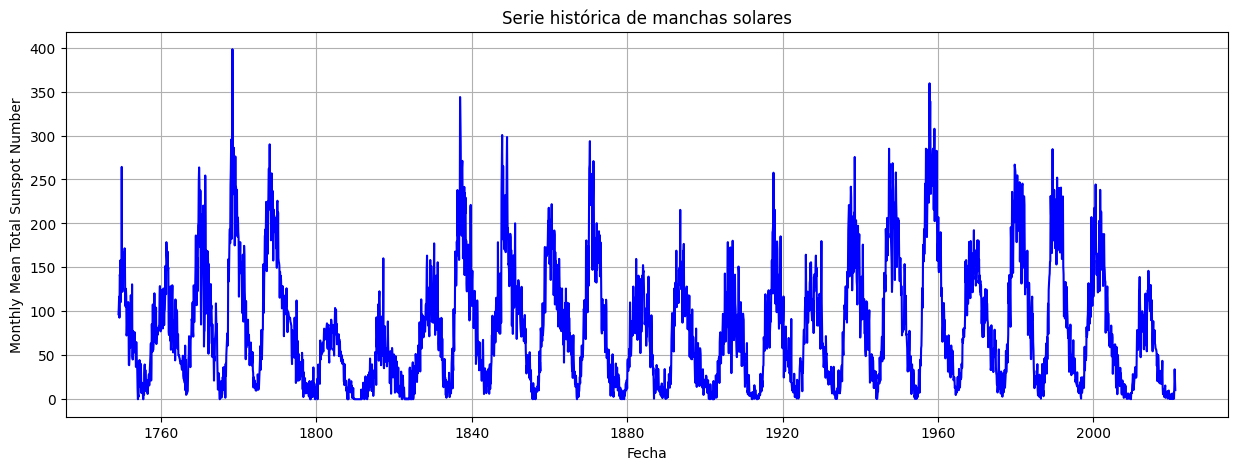

In [41]:
plt.figure(figsize=(15,5))
plt.plot(df_sunspots["date"], df_sunspots["sunspots"], color='blue')
plt.title("Serie histórica de manchas solares")
plt.xlabel("Fecha")
plt.ylabel("Monthly Mean Total Sunspot Number")
plt.grid(True)
plt.show()

Podemos ver que nuestra serie de tiempo no sigue una tendencia pero si cierta periocidad entre años, en donde hay epocas en que ocurren mas o menos cantidad de manchas solares.

Un ejemplo de estos son los años 2000 que se puede ver que tiene mas manchas solares que los años pasados , pero menos que 1990.

Ahora vamos a hacer un analisis mas profundo descomponiendo la serie

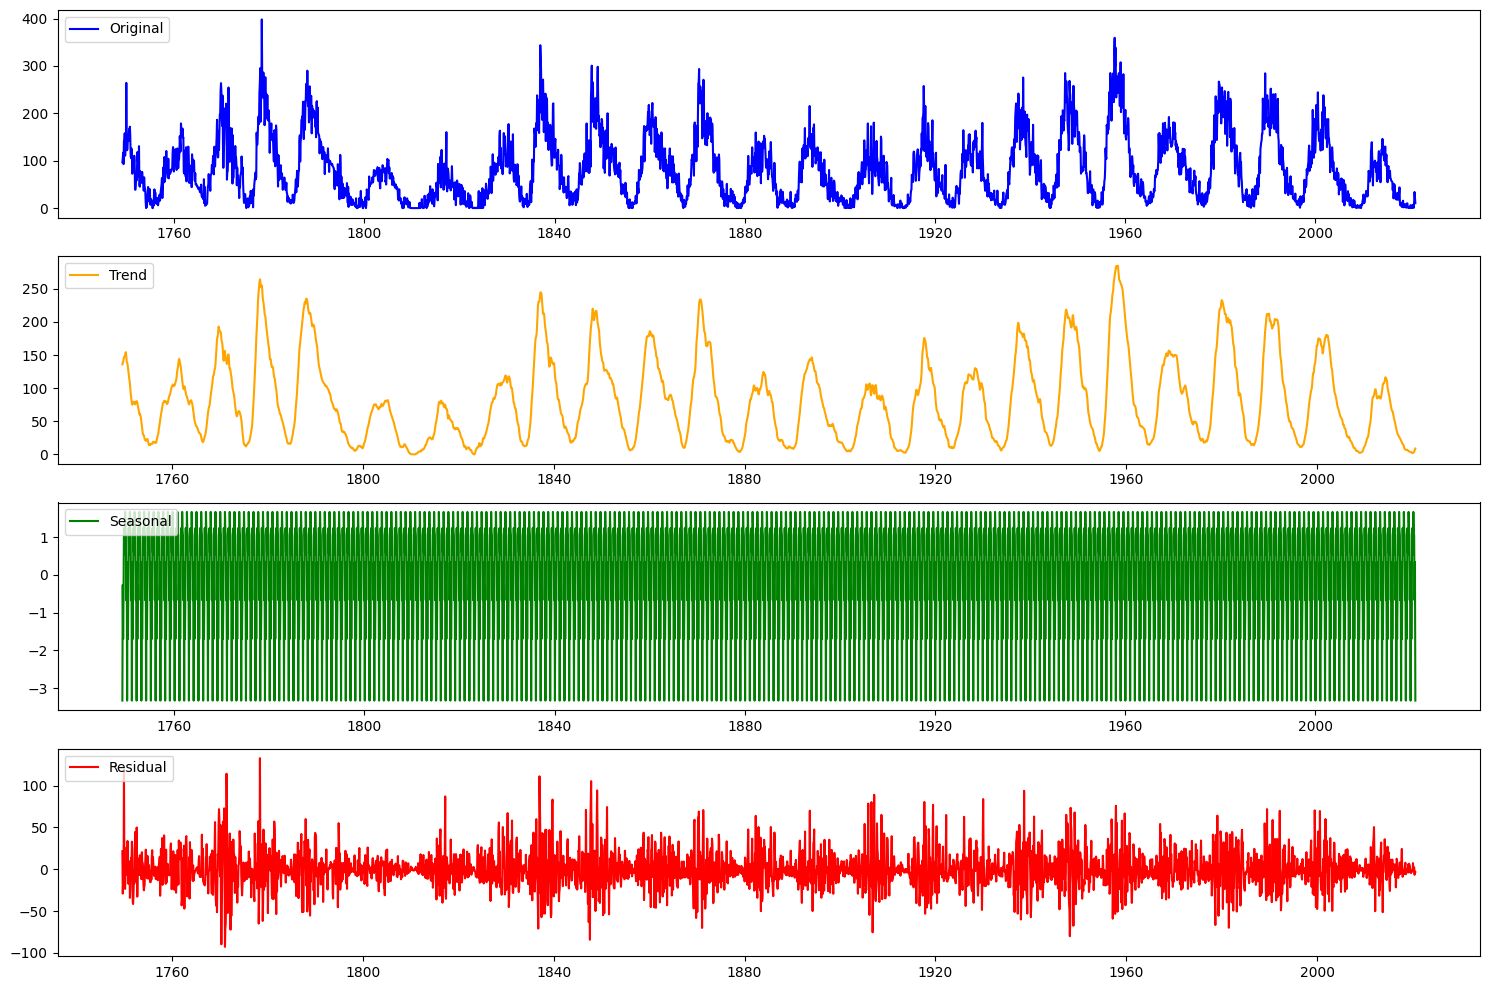

In [42]:
df_sunspots.set_index("date", inplace=True)

decomposition = seasonal_decompose(df_sunspots["sunspots"], model='additive', period=12)

# Extraer componentes
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Graficar componentes
plt.figure(figsize=(15,10))

plt.subplot(4,1,1)
plt.plot(df_sunspots["sunspots"], label='Original', color='blue')
plt.legend(loc='upper left')

plt.subplot(4,1,2)
plt.plot(trend, label='Trend', color='orange')
plt.legend(loc='upper left')

plt.subplot(4,1,3)
plt.plot(seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')

plt.subplot(4,1,4)
plt.plot(residual, label='Residual', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


Podemos ver que la serie tiene varias cosas.

- No tiene tendencia es totalmente sin tendencia lo cual la hace estacionario en media pero no en varianza ya que entre periodos hay mucha variacion.

- Si es estacional, ya que se mira un periodo en que crece o baja las manchas solares.

Ahora vamos a Normalizarla. Convirtiendo a vlaores de -1 y 1

In [43]:
series = df_sunspots["sunspots"].values.reshape(-1,1)
scaler = MinMaxScaler(feature_range=(0,1))
series_scaled = scaler.fit_transform(series)

Definimos nuestra GPU

In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)


Usando device: cuda


Y creamos nuestra serie en el device de la GPU

In [45]:
series_tensor = torch.tensor(series_scaled, dtype=torch.float32).to(device)


Ahora creamos las secuencias para RNN

In [46]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return torch.stack(X), torch.stack(y)

Usamos una ventana de 12 meses ya que la estacionaliedad es anual

## RNN

### Primera venta de 10 meses

In [47]:
seq_length = 10
X_tensor, y_tensor = create_sequences(series_tensor, seq_length)

print("Forma de X:", X_tensor.shape)
print("Forma de y:", y_tensor.shape)


Forma de X: torch.Size([3255, 10, 1])
Forma de y: torch.Size([3255, 1])
